In [1]:
import argparse
import json
import sys
import traceback
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from proj2dhullsampler.run_apply import load_config
from proj2dhullsampler.pipeline import build_case, default_worker_count

In [4]:
from proj2dhullsampler.sampling_functions import _one_batch, sample_from_hull

# Goal:
The goal of this notebook is to test and visualize functions that (1) drop the structural error-prone variables and (2) implemented after build_case, and after the variables name are dropped.

## Workflow:
We focus on the following funs in the workflosw:

- Functions that drop structural error-prone variables
  - self.drop_by_name
  - self.drop_by_emulator_performance
  - self.drop_by_n_survive
  - self.remove_var2d_auto
  - test_case.drop_by_nvar_per_pair


- self.prepare_for_sampling:
  - self.build_hulls
    - build_hulls
    - self.orchestrate
      - orchestrate_test (defined in sampling functions)
        - sample_from_hulls_n (defined in sampling functions)
          - _one_batch (defined in sampling functions)
            - sample_from_hull (defined in sampling functions)
                
        - test_ind_vars (defined in sampling functions)

- self.draw:
  - sample_from_hulls_n
   



In [5]:
config_path = "../application/apply_test.json"
config = load_config(config_path)

In [6]:
mode = 'notebook'

In [7]:
1 in [1,2,3]

True

Worker count: prepare_case.n_cpus=32 (job allocation reports 8 CPUs available; an explicit config value, if set, takes precedence)
Case directory does not exist yet; creating and preparing it.
Start creating new case
obs and ppe variable names match


/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

<class 'pandas.core.frame.DataFrame'>
            0
y0   0.000000
y1   0.000000
y2   0.000000
y3   0.000000
y4   0.000000
y5   0.000000
y6   0.000000
y7   0.000000
y8   0.000000
y9   0.000000
y10  0.000000
y11  0.000000
y12  0.003333
y13  0.000000
y14  0.003333
y15  0.006667
y16  0.006667
y17  0.003333
y18  0.010000
y19  0.013333
y20  0.000000
y21  0.010000
y22  0.010000
y23  0.016667
y24  0.000000
y25  0.006667
y26  0.006667
y27  0.013333
y28  0.013333
y29  0.010000


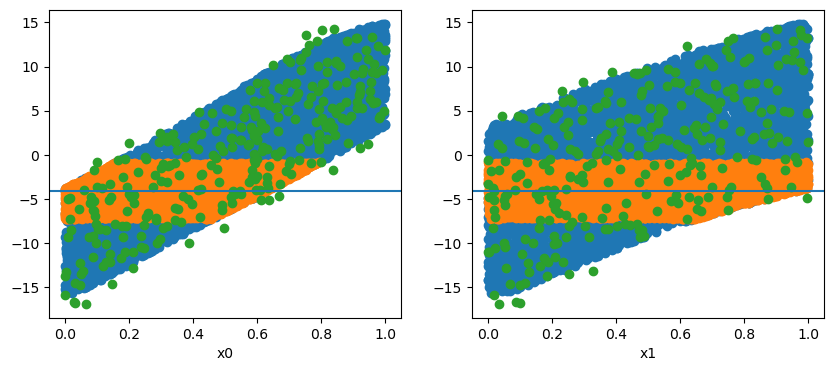

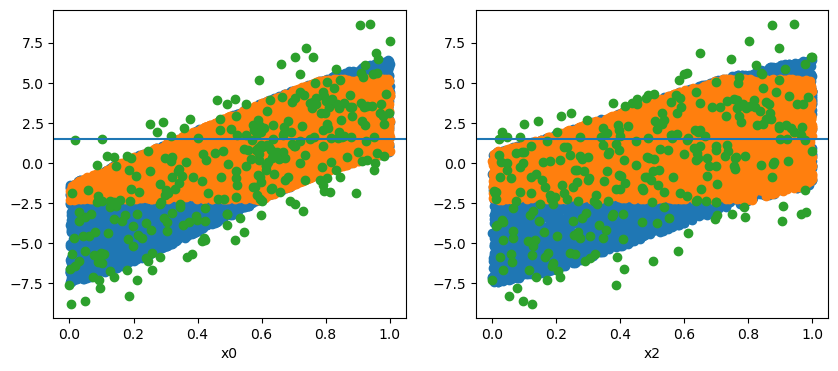

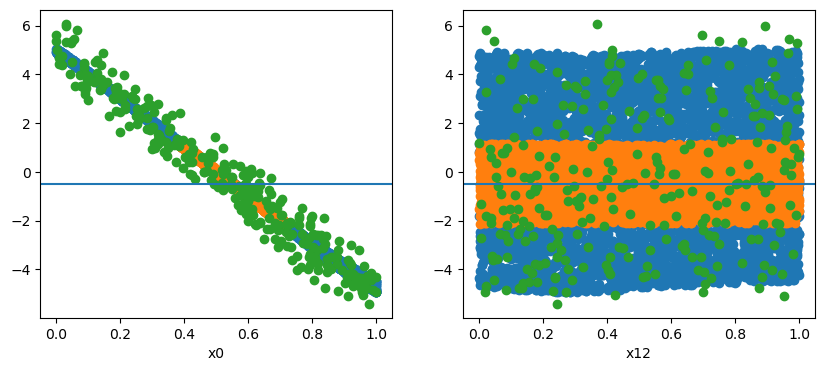

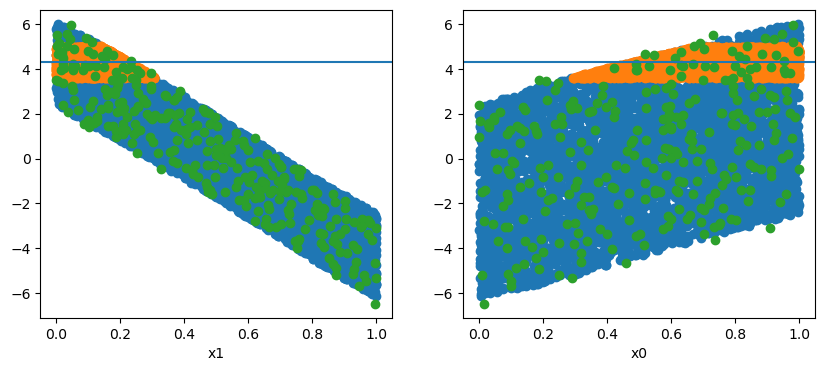

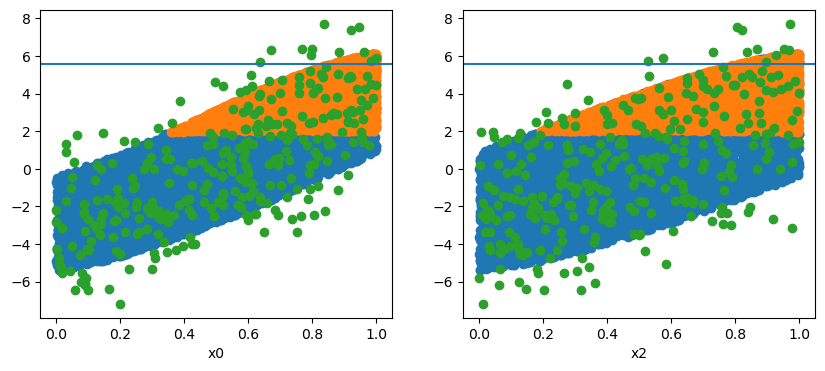

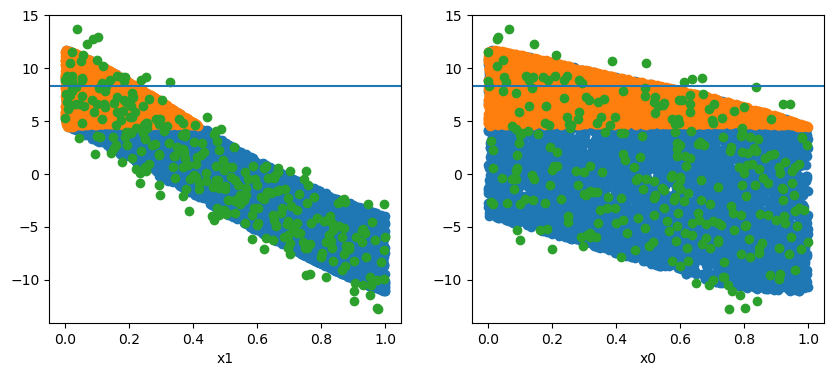

In [8]:
test_case = build_case(config, mode=mode, on_created=None)

## Functions that drop the variables
They all have to do the following:
- Determine the variables to drop;
- Store them in self.dropped_vars
- update self.tf_masks
- update self.var_nm
- update_meta, which updates the self.meta table by dropping the corresponding variable columns



### drop_by_name, drop_by_emulator_performance, drop_by_n_survive
drop_by_name: as its name implied, drop certain variables that we want to exclude them by their names. Note that if we have a group of variables such as y1, y2, y3, by specifying vars_to_drop to be "y", they will all be dropped, because we startwith is used

````python
var_to_drop.extend([s for s in self.var_nm if s.startswith(v)])
````


drop_by_emulator_performance and drop_by_n_survive are relatively straightforward functions. Check the codes in hm_class.py for more details

In [9]:

test_case.drop_by_name(config["vars_to_drop"])
test_case.drop_by_emulator_performance(config["emultor_error_ratio_threshold"])
test_case.drop_by_n_survive(config["n_survive_threshold"])

Drop variables [] based on hand selection
Drop variables [] based on emulator perfornace (error ratio of 0.2 as threshold)
Drop variables ['y21', 'y16', 'y29', 'y20', 'y18', 'y14'] because they do not help constrain the parameters
Drop variables [] because they constrain the parmaeters too much


In [10]:

test_case.remove_var2d_auto(config["n_survive_threshold_2d"], added_num = config['added_number_for_pairs'])
test_case.drop_by_nvar_per_pair(config['n_var_thre'])


x0                                       and x1                                      :     3446
x2                                       and x3                                      :     3740
There are 2 groups that have no overlapping within own groups
Drop variable ['y3']
x2                                       and x3                                      :     3740
There are 1 groups that have no overlapping within own groups
Drop variable ['y8']
There are 0 groups that have no overlapping within own groups
No non-overlapping variables at this stage for the variables sharing the same 2 sensitive parameters
Finished dropping variables
Drop variables [] because when grouped together, they contribute to too little surviving ensemble members


## build_hulls

In [11]:
test_case.build_hulls()


In [154]:
no_para_pair = 1

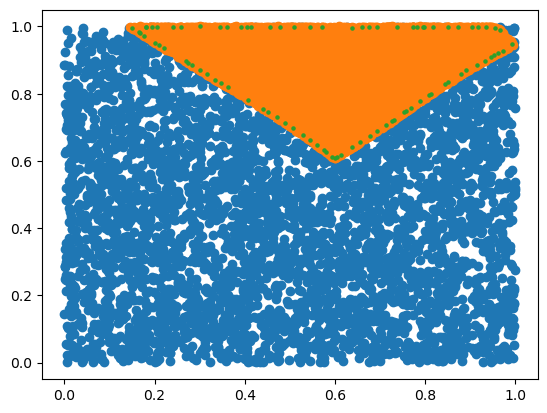

In [155]:
specific_vars = list(test_case.paras_vars.values())[no_para_pair]
specific_pair = list(test_case.paras_vars.keys())[no_para_pair]
specific_tf = test_case.tf_masks[list(specific_vars)].all(axis = 1)

subspace_p_emu = test_case.p_emu[list(list(test_case.paras_vars.keys())[no_para_pair])]
plt.scatter(subspace_p_emu.iloc[:5000,0], subspace_p_emu.iloc[:5000,1])
plt.scatter(subspace_p_emu[specific_tf].iloc[:,0], subspace_p_emu[specific_tf].iloc[:,1])


hull = list(test_case.grouped_hulls.values())[no_para_pair]
coords = np.asarray(hull.exterior.coords)   # (n, 2); first vertex repeated as last
plt.scatter(coords[:, 0], coords[:, 1], s=5)

## sample_from_hull

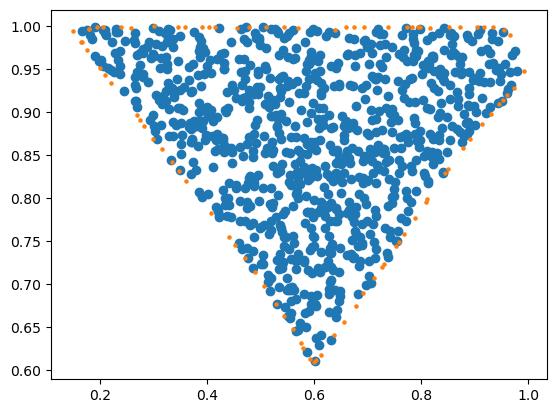

In [156]:
hulled_samples = sample_from_hull(test_case.p_emu[:5000], specific_pair, hull)
plt.scatter(hulled_samples[specific_pair[0]], hulled_samples[specific_pair[1]])
plt.scatter(coords[:, 0], coords[:, 1], s=5)

## _one_batch

In [157]:
pair_max = 2

In [158]:
pairs = list(test_case.grouped_hulls.keys())[:pair_max]
multi_hulled_samples = _one_batch((pairs, test_case.para_nm, test_case.grouped_hulls, 10000, 1))

In [159]:
pairs

[('x2', 'x4'), ('x1', 'x2')]

Text(0, 0.5, 'x4')

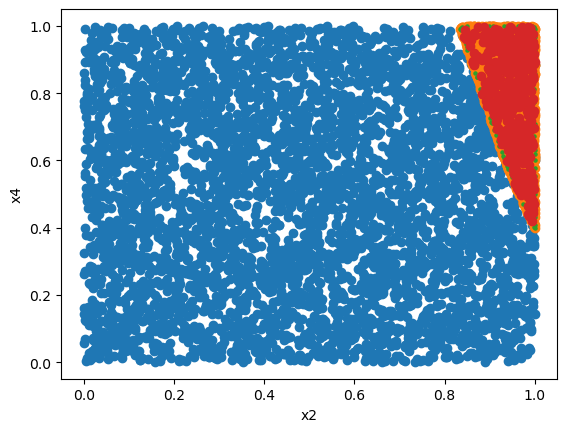

In [167]:
specific_vars0 = list(test_case.paras_vars.values())[0]
specific_pair0 = list(test_case.paras_vars.keys())[0]
specific_tf0 = test_case.tf_masks[specific_vars0].all(axis = 1)

subspace_p_emu0 = test_case.p_emu[list(list(test_case.paras_vars.keys())[0])]
plt.scatter(subspace_p_emu0.iloc[:5000,0], subspace_p_emu0.iloc[:5000,1])
plt.scatter(subspace_p_emu0[specific_tf0].iloc[:,0], subspace_p_emu0[specific_tf0].iloc[:,1])


hull0 = list(test_case.grouped_hulls.values())[0]
coords0 = np.asarray(hull0.exterior.coords)   # (n, 2); first vertex repeated as last
plt.scatter(coords0[:, 0], coords0[:, 1], s=5)
plt.scatter(multi_hulled_samples[specific_pair0[0]], multi_hulled_samples[specific_pair0[1]])
plt.xlabel(specific_pair0[0])
plt.ylabel(specific_pair0[1])


Text(0, 0.5, 'x2')

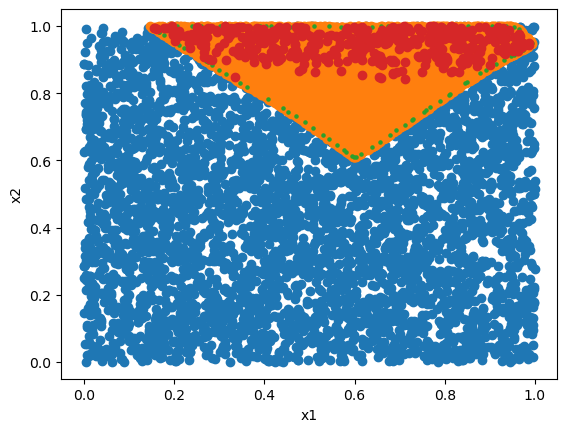

In [168]:
specific_vars1 = list(test_case.paras_vars.values())[1]
specific_pair1 = list(test_case.paras_vars.keys())[1]
specific_tf1 = test_case.tf_masks[specific_vars1].all(axis = 1)

subspace_p_emu1 = test_case.p_emu[list(list(test_case.paras_vars.keys())[1])]
plt.scatter(subspace_p_emu1.iloc[:5000,0], subspace_p_emu1.iloc[:5000,1])
plt.scatter(subspace_p_emu1[specific_tf1].iloc[:,0], subspace_p_emu1[specific_tf1].iloc[:,1])


hull1 = list(test_case.grouped_hulls.values())[1]
coords1 = np.asarray(hull1.exterior.coords)   # (n, 2); first vertex repeated as last
plt.scatter(coords1[:, 0], coords1[:, 1], s=5)
plt.scatter(multi_hulled_samples[specific_pair1[0]], multi_hulled_samples[specific_pair1[1]])
plt.xlabel(specific_pair1[0])
plt.ylabel(specific_pair1[1])

In [22]:
tf_masks = test_case.tf_masks
tf_masks_raw = test_case.tf_masks_raw
p_emu = test_case.p_emu


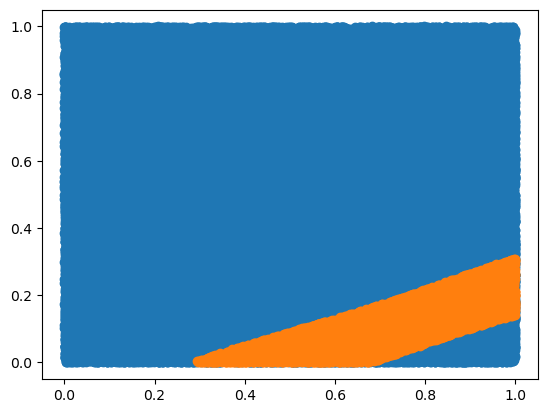

In [23]:
plt.scatter(p_emu['x0'], p_emu['x11'])
plt.scatter(p_emu['x0'][tf_masks_raw['y3']], p_emu['x1'][tf_masks_raw['y3']])


In [32]:
tf_masks_raw[['y3', 'y0', 'y5', 'y6']].all(axis = 1).sum()

4713

In [39]:
tf_masks_raw[['y8', 'y13']].all(axis = 1).sum()

3740

In [40]:
tf_masks_raw[['y8']].all(axis = 1).sum()

14732

In [41]:
tf_masks_raw[['y13']].all(axis = 1).sum()

19333